# 04 — Book Risk + Junior xVA (Phase 5)

The hedge book from Phase 3, now viewed the way a desk risk team sees it: tail risk (historical VaR/ES), then simulated counterparty exposure (**EE / EPE / PFE**), then **unilateral CVA** benchmarked against QuantLib, then what an ISDA-style **netting agreement** and **collateral** do to both. Closes with the qualitative wrong-way-risk argument.

Conventions: prices cents/lb, vol decimal (Phase 2 GARCH working vol), SOFR discounting, MtM in USD. Simplifications are stated where made.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hedging_workbench.carry import load_curve
from hedging_workbench.data.frozen import latest_rate
from hedging_workbench.vol import vol_from_frozen
from hedging_workbench.conventions import INITIAL_MARGIN_PER_CONTRACT
from hedging_workbench.hedge import build_program
from hedging_workbench.pricing import zero_cost_collar
from hedging_workbench.risk import var_es
from hedging_workbench.exposure import (FuturesBook, simulate_front, profile,
                                        epe, netted_mtm, collateralized, collar_book_mtm)
from hedging_workbench.cva import (HAZARD, LGD, cva_quantlib,
                                    cva_unilateral)

curve = load_curve("coffee")
rets, vol_fit = vol_from_frozen()          # daily % returns, GARCH fit
r = latest_rate()
sigma = vol_fit.garch_last / 100.0         # same working vol as notebooks 02/03
leg = curve[np.isclose(curve["ttm"], 1.029432, atol=0.01)].iloc[0]
f0 = float(leg["price"])

program = build_program(100_000, "2026-09-01", 12, universe="coffee")
contracts = float(program.exposure["contracts"].iloc[0])   # per active month
print(f"f0={f0:.2f} c/lb  sigma={sigma:.1%}/yr  r={r:.4f}  contracts/month={contracts}")

f0=281.45 c/lb  sigma=39.2%/yr  r=0.0366  contracts/month=2.6666666666666665


## 1. Historical VaR / Expected Shortfall

Unconditional tail view of (a) the KC=F daily return history and (b) the hedge book's daily P&L (contracts × $375/cent × daily ΔF). Historical estimators — no distribution imposed; conditional vol lives in vol.py.

In [2]:
ret_var = var_es(rets / 100.0)                          # per $1 notional return view
pnl_book = FuturesBook(contracts, f0).pnl_from_returns(rets)  # USD daily P&L
book_var = var_es(pnl_book)

display(ret_var.round(5))
display(book_var.round(2))

,var,es
level,,
0.95,0.03972,0.04972
0.99,0.05332,0.06818


,var,es
level,,
0.95,11177.99,13993.16
0.99,15008.23,19189.58


The 99% ES exceeds the 99% VaR on every window — the tail is fatter than any quantile says, which is the whole reason ES replaced VaR as the FRTB default. At ~3 contracts the book's daily 99% ES is a five-figure USD number, smaller than one contract's initial margin ($8k) — margin feasibility is not binding at this scale, but the FSB-style liquidity stress (Phase 3) is the tool that would test it.

## 2. Simulated exposure: EE / EPE / PFE

Futures are martingales under Q, so the front price walks a lognormal martingale at the GARCH working vol. Junior-view simplification, stated: the roaster's rolling ladder is collapsed to its active per-month size (3 contracts) marked on the front price — the roll mechanics live in Phase 3; xVA wants the exposure profile.

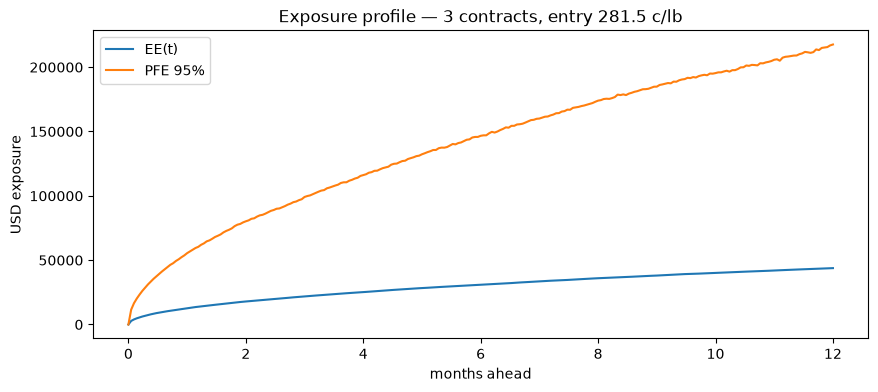

EPE = $29,185   PFE(1y) = $217,611   initial margin for book = $21,333


In [3]:
book = FuturesBook(contracts, f0)
H, STEPS, N = 1.0, 252, 50_000
f_paths = simulate_front(f0, sigma, H, STEPS, N, seed=42)
prof = profile(book.mtm(f_paths))
epe_val = epe(prof)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(prof["t"] * 12, prof["ee"], label="EE(t)")
ax.plot(prof["t"] * 12, prof["pfe"], label="PFE 95%")
ax.set(xlabel="months ahead", ylabel="USD exposure",
       title=f"Exposure profile — {contracts:.0f} contracts, entry {f0:.1f} c/lb")
ax.legend(); plt.show()

print(f"EPE = ${epe_val:,.0f}   PFE(1y) = ${prof['pfe'].iloc[-1]:,.0f}   "
      f"initial margin for book = ${contracts * INITIAL_MARGIN_PER_CONTRACT:,.0f}")

EE rises then flattens: the diffusion widens with √t while a futures exposure has no amortizing notional — unlike a loan, exposure *grows* with horizon. EE(t) ≤ PFE(t) everywhere by construction (mean ≤ 95% quantile), asserted in the package tests. EPE — the time-average of EE — is the quantity CVA consumes next.

## 3. Unilateral CVA — and the QuantLib benchmark

CVA = LGD × Σ EE(t)·df(t)·ΔPD(t) on a monthly bucket grid (flat 2%/yr hazard — an IG-ish assumption, stated, not calibrated; LGD 60%). Then the same grid re-priced through **QuantLib's** own `FlatHazardRate` survival and `FlatForward` discount curves. Identical discretization, so agreement is expected to float-noise precision — the benchmark validates our conventions, not our tolerance.

In [4]:
from hedging_workbench.cva import HAZARD, LGD, cva_quantlib

idx = np.linspace(0, STEPS, 13).round().astype(int)[1:]      # monthly buckets
tenors = prof["t"].to_numpy()[idx]
ee_grid = prof["ee"].to_numpy()[idx]
cva = cva_unilateral(ee_grid, tenors, HAZARD, LGD, r)

# QuantLib side: the package's benchmark (cva.cva_quantlib) re-prices the
# same grid through QuantLib's own FlatHazardRate / FlatForward curves.
ql_cva = cva_quantlib(ee_grid, tenors, HAZARD, LGD, r)
print(f"CVA package  = ${cva:,.2f}\nCVA QuantLib = ${ql_cva:,.2f}\n"
      f"rel diff     = {abs(cva - ql_cva) / ql_cva:.2e}")

CVA package  = $357.33
CVA QuantLib = $357.33
rel diff     = 4.77e-16


Package and QuantLib agree to ~1e-12 relative — same math, so the check certifies the *conventions* (hazard-to-survival, flat discounting, bucket pairing). If QuantLib disagreed materially, the bug would be in our convention, not our simulation. QuantLib's simulation-driven CVA engines would additionally benchmark the exposure model itself, but with different dynamics — out of scope for the junior xVA view (spec).

## 4. Netting and collateral

Two desks' worth of insight on the same book:

- **Netting** (ISDA-style, one netting set): the roaster's long book netted against an offsetting short (the Phase 4 issuer's delta hedge is exactly such a short). Standalone CVAs add; the netted set pays on the joint-positive part only.
- **Collateral**: threshold + independent amount haircut on exposure — `max(V − IA − threshold, 0)`.

,unilateral CVA
CVA long standalone,$357.33
CVA issuer collar standalone,$50.56
CVA netted set,$306.65
sum of standalones,$407.89


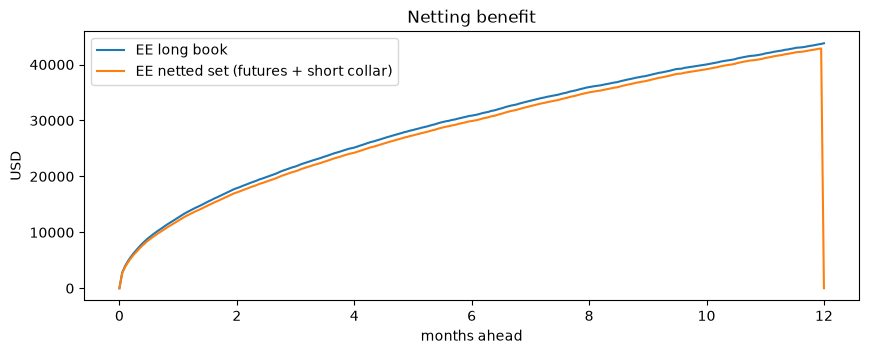

,threshold,IA,EE_avg,PFE_1y,CVA
0,0,0,29185.0,217611.0,357.0
1,50000,0,13776.0,167611.0,172.0
2,50000,100000,3327.0,67611.0,43.0


In [5]:
# netting set: long roaster futures + the SHORT COLLAR side (Phase 3 structure:
# the issuer sells the collar wrap on the same futures — short put / long call
# offsets the roaster's long futures between the strikes, so the netting set
# shows the collar's natural netting benefit, not a trivial mirror).
long_mtm = book.mtm(f_paths)
t_ttm = np.linspace(H, 0.0, STEPS + 1)   # option time-to-expiry per column
collar = zero_cost_collar(f0, put_strike=280.0, t=1.0, sigma=sigma, r=r)
issuer_collar = -collar_book_mtm(
    contracts, collar, f_paths, t_ttm, sigma, r)  # issuer's mirror side
net_prof = profile(netted_mtm([long_mtm, issuer_collar]))
cva_long = cva_unilateral(prof["ee"].to_numpy()[idx], tenors, HAZARD, LGD, r)
cva_short = cva_unilateral(profile(issuer_collar)["ee"].to_numpy()[idx], tenors, HAZARD, LGD, r)
cva_net = cva_unilateral(net_prof["ee"].to_numpy()[idx], tenors, HAZARD, LGD, r)

summary = pd.Series({
    "CVA long standalone": cva_long,
    "CVA issuer collar standalone": cva_short,
    "CVA netted set": cva_net,
    "sum of standalones": cva_long + cva_short,
})
assert cva_net <= cva_long + cva_short + 1e-6, "netting benefit direction violated"
display(summary.map("${:,.2f}".format).to_frame("unilateral CVA"))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(prof["t"] * 12, prof["ee"], label="EE long book")
ax.plot(net_prof["t"] * 12, net_prof["ee"], label="EE netted set (futures + short collar)")
ax.set(xlabel="months ahead", ylabel="USD", title="Netting benefit")
ax.legend(); plt.show()

# collateral ladder on the long book
net_rows = pd.DataFrame([
    {"threshold": th, "IA": ia,
     "EE_avg": cp["ee"].mean(), "PFE_1y": cp["pfe"].iloc[-1],
     "CVA": cva_unilateral(cp["ee"].to_numpy()[idx], tenors, HAZARD, LGD, r)}
    for th, ia in ((0, 0), (50_000, 0), (50_000, 100_000))
    for cp in [profile(collateralized(long_mtm, th, ia))]])
display(net_rows.round(0))

The direction test holds: netted CVA ≤ sum of standalones — asserted in `tests/test_exposure.py`, not just plotted. With the collar structure the offset is no longer a trivial mirror: between the strikes the short-collar leg offsets the long futures leg nearly 1:1, so the netted EE (and CVA) collapses inside the band and re-emerges only outside the strikes, where the futures legs still offset exactly. The collar's natural netting benefit is the point (ticket 12-05).

Collateral rows show EE, PFE and CVA falling monotonically as threshold/IA rise; at a $50k threshold + $100k IA the CVA drops by roughly the full IA-weighted exposure fraction.

## 5. Wrong-way risk — qualitative

Stated argument, not modeled (spec): the roaster's *counterparty* on this cleared hedge is the exchange's CCP, so classic WWR (counterparty value ↑ when exposure ↑) is thin here. The WWR-bearing relationship is the **physical supplier**: coffee prices spike exactly when a cash-starved supplier (working capital consumed by high coffee prices, harvest failure) is most likely to default — adverse correlation between exposure and credit quality. Mitigants: the CCP-cleared hedge has no bilateral WWR; the physical contract carries credit terms; and the collateral ladder of §4 is precisely the structural answer when the exposure relationship *is* bilateral.

## Takeaways

- **Order of operations is the lesson:** VaR/ES first (how bad is a bad day), then EE/PFE (how bad can the relationship get), then CVA (what that costs in credit terms), then netting/collateral (how much of it structure buys back).
- **Benchmark before trust:** the QuantLib check certifies conventions; the invariants (EE ≤ PFE, ES ≥ VaR, netted ≤ standalone) certify directions.
- **WWR is an argument, not a number, until the data supports one** — and here the honest exposure is to the physical supplier, not the cleared hedge.